# Introduction and Reusable code definition

Draft of the thesis code. First, the data is uploaded. Then, few basic operations are performed to calculate mean values of every modality and median. They will serve as a base line for any future modality prediction.

In [27]:
#Nessesary imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

#It might be the case that some of the imports below are redundant
import torch
import torch.nn as nn
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch.optim as optim
import torchaudio
import glob
import os
import time
import random
import copy

In [28]:
file_path = "/content/drive/MyDrive/ThesisData/WQI.xlsx"
df = pd.read_excel(file_path, usecols="H:R") #columns H to R have actual modalities

# Statistics by column
stats = pd.DataFrame({
    "mean": df.mean(),
    "variance": df.var(),
    "median": df.median()
})


display(stats)

,mean,variance,median
Avg Of Temp,2.907332e+01,7.297798e-01,2.908333e+01
Avg Of pH,7.204085e+00,4.899476e-02,7.200000e+00
Avg Of DO,1.743602e+00,1.416011e+00,1.691667e+00
Avg Of BOD,1.272242e+01,7.946888e+01,1.008333e+01
Avg Of SS,2.525573e+01,2.512322e+02,2.116667e+01
Avg Of TKN,7.637407e+00,1.864455e+01,6.900000e+00
Avg Of NH3,4.117166e+00,1.268854e+01,3.166667e+00
Avg Of NO2,1.534683e-01,1.646398e-02,1.241667e-01
Avg Of NO3,1.768828e+00,6.166506e-01,1.875000e+00
Avg Of TP,8.928586e-01,2.026793e-01,8.333333e-01


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Next, I devide the data into Train, Validation, and Test batches. The data is divided randomly. This is nessesary because the data is ordered chronoligically. This means, that model trained exclusively on the data form one period of time might underperform with data from another time period. However, static seed is used to get repeatable results.
The data is divided as 50% train, 25% validation, and 25% test.

In [30]:
SEED = 1

train_df, temp_df = train_test_split(
    df, test_size=0.5, random_state=SEED, shuffle=True
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3250, 11)
Validation shape: (1625, 11)
Test shape: (1626, 11)


In [31]:
def extract_xy_splits(train_df, validation_df, test_df, feature_cols, target_col):

    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_validation, y_validation = validation_df[feature_cols], validation_df[target_col]
    X_test, y_test = test_df[feature_cols], test_df[target_col]

    return X_train, y_train, X_validation, y_validation, X_test, y_test

# Linear regression
The reason why I start with linear rgression is because it is easy to code and analyze, as well as it gives easy interpretation by showing which modalities affect the prediction the most.
Here, I try to predict each feature separately.


In [32]:
results = []

for target_col in df.columns:
    # Use all other modalities except for target one as inputs
    feature_cols = [c for c in df.columns if c != target_col]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    test_pred = model.predict(X_test)

    # Metrics
    results.append({
        "Target": target_col,
        "R2": r2_score(y_test, test_pred),
        "Mean absolute error": mean_absolute_error(y_test, test_pred),
        "Mean square error": np.sqrt(mean_squared_error(y_test, test_pred))
    })

linear_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(linear_df)

,Target,R2,Mean absolute error,Mean square error
4,Avg Of SS,0.000001,9.934284e+00,1.488957e+01
9,Avg Of TP,-0.000074,3.672899e-01,4.509887e-01
7,Avg Of NO2,-0.000123,9.498863e-02,1.353115e-01
1,Avg Of pH,-0.000757,1.814262e-01,2.278085e-01
8,Avg Of NO3,-0.001797,6.292060e-01,7.937479e-01
0,Avg Of Temp,-0.001968,6.660754e-01,8.876402e-01
6,Avg Of NH3,-0.002655,2.763335e+00,3.525822e+00
5,Avg Of TKN,-0.003089,3.373557e+00,4.334185e+00
3,Avg Of BOD,-0.003655,6.242323e+00,8.651013e+00
2,Avg Of DO,-0.007359,9.989967e-01,1.213975e+00


The results show R2 score near zero or negative for almost every modality. This might suggest, that either none of the modalities has linear relation to others, or that the data has outliers that prevent a good line fit.
Here, I'll test the data by looking for minimum and maximum values of each modality, as well as plotting the distribution of some modalities.

In [34]:
# Statistics by column
stats = pd.DataFrame({
    "mean": df.mean(),
    "min": df.min(),
    "max": df.max()
})


display(stats)

,mean,min,max
Avg Of Temp,2.907332e+01,24.500000,3.200000e+01
Avg Of pH,7.204085e+00,6.333333,8.609091e+00
Avg Of DO,1.743602e+00,0.000000,8.508333e+00
Avg Of BOD,1.272242e+01,2.000000,8.450000e+01
Avg Of SS,2.525573e+01,4.000000,3.700000e+02
Avg Of TKN,7.637407e+00,0.600000,3.249167e+01
Avg Of NH3,4.117166e+00,0.000000,2.476667e+01
Avg Of NO2,1.534683e-01,0.000000,2.650000e+00
Avg Of NO3,1.768828e+00,0.000000,5.383333e+00
Avg Of TP,8.928586e-01,0.091667,3.525000e+00


We see that there are odd values in dataset. Namely:
Temp, BOD, SS, TKN NO2, and TP all have a little bit suspiciously round values of minimum and/or maximum.
DO, NH3, NO2, NO3 have 0 as a minimum, which might suggest error in measurements.
TColiform has a huge difference between min, mean, and max.
I'll plot the distribution of modalities to see if there is some other odd values.

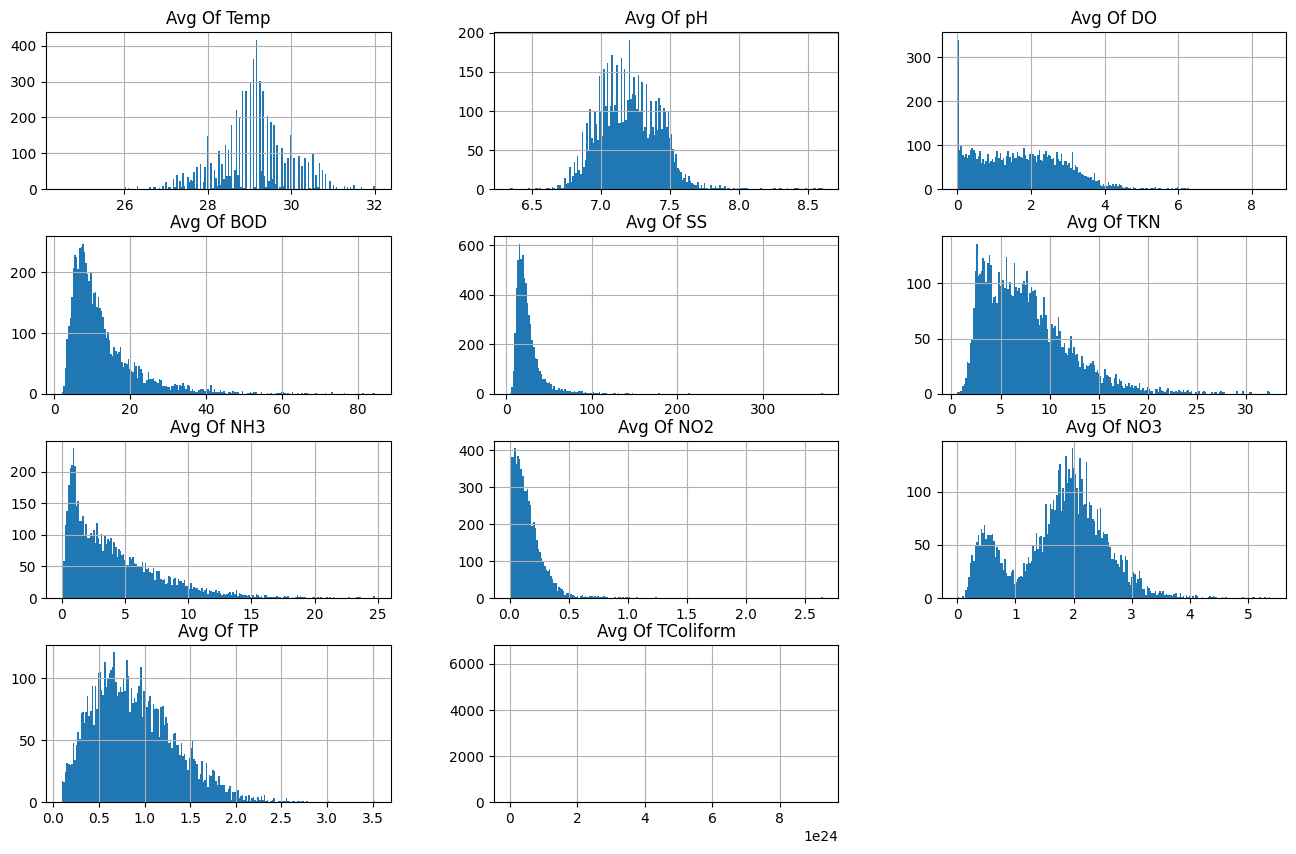

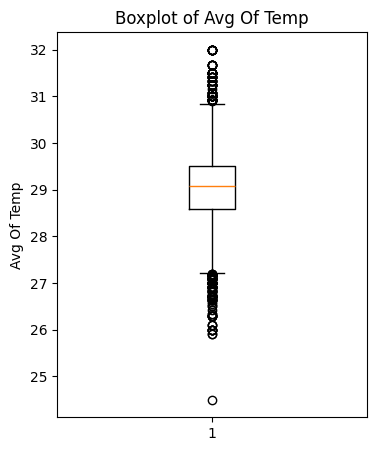

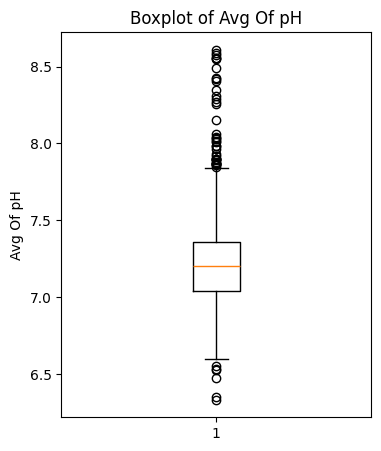

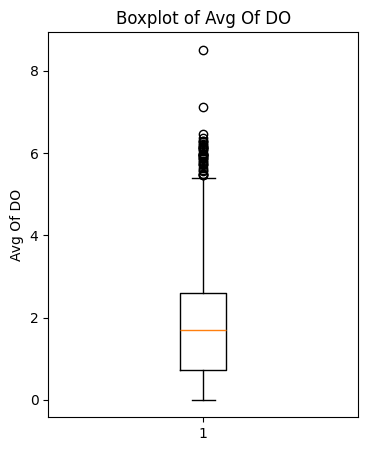

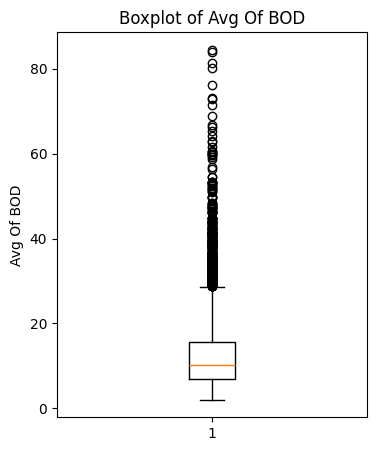

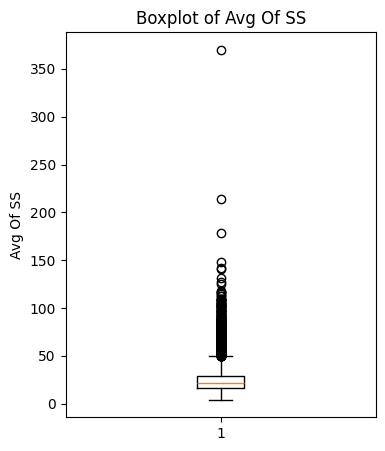

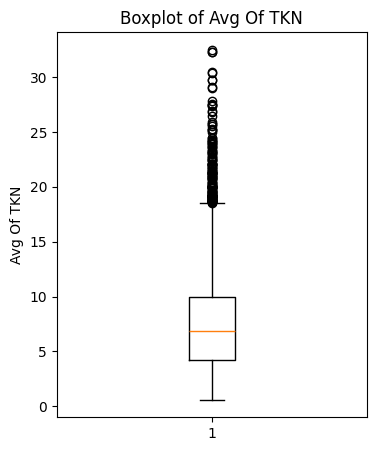

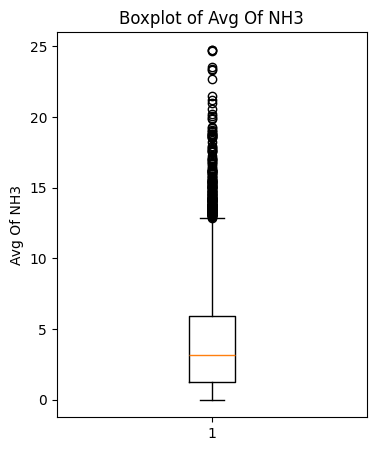

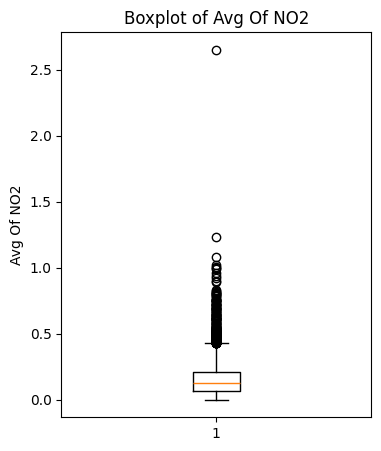

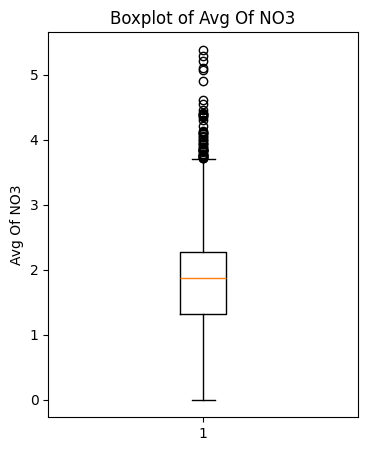

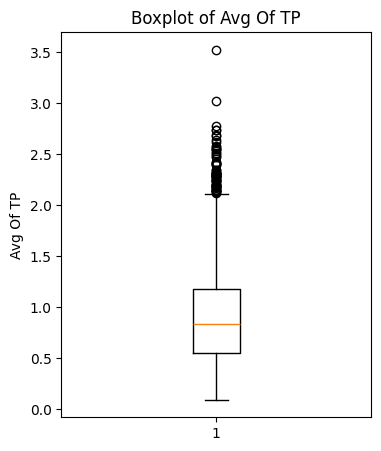

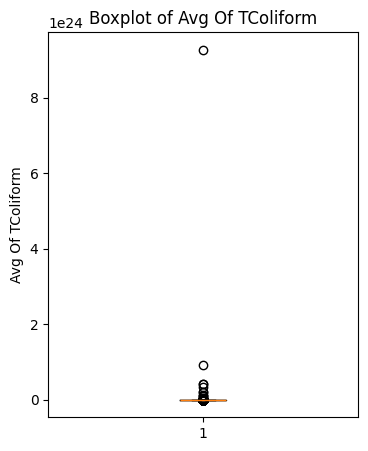

In [35]:
# df_num = numeric columns H:R
df.hist(figsize=(16, 10), bins=200)
plt.show()


for col in df.columns:
    plt.figure(figsize=(4, 5))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

Another possibility is that there is no linear relation between modalities in general dataset, but it is worth trying to test the resuls by testing and training model for each individual location.

As a temporary fix, I've removed last TColiform modality from the training set, as it has clear outliers

In [33]:
results = []

for target_col in df.columns:
    # Use all other modalities except for target one as inputs
    feature_cols = [c for c in df.columns[0:9] if c != target_col]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    test_pred = model.predict(X_test)

    # Metrics
    results.append({
        "Target": target_col,
        "R2": r2_score(y_test, test_pred),
        "Mean absolute error": mean_absolute_error(y_test, test_pred),
        "Mean square error": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

linear_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(linear_df)

,Target,R2,Mean absolute error,Mean square error
5,Avg Of TKN,0.907862,9.790815e-01,1.313583e+00
6,Avg Of NH3,0.880966,8.768417e-01,1.214841e+00
3,Avg Of BOD,0.642629,3.561547e+00,5.162195e+00
9,Avg Of TP,0.566920,2.259039e-01,2.967792e-01
2,Avg Of DO,0.552133,5.997083e-01,8.094539e-01
1,Avg Of pH,0.375432,1.379274e-01,1.799681e-01
8,Avg Of NO3,0.351606,5.012539e-01,6.385753e-01
7,Avg Of NO2,0.202366,8.391752e-02,1.208397e-01
4,Avg Of SS,0.167624,9.073028e+00,1.358446e+01
0,Avg Of Temp,0.153827,6.239737e-01,8.157172e-01


# K-Neighbouts Regression
K-Neighbouts regression finds k nearest neighbouts and averages them to get the result.

In the code below, I try to test K-Neighbouts Regression for each modality (same as was done with linear regression). However, due to configurable nature of K-Neighbouts Regression I also try to find best parameters for model (for each modality). Namely, I'm searching for optimal amount of nearest neighbouurs, best model weights (uniform vs inverse-of-distance), and best distance estimation (Manhattan vs Euclidean).

Apart from the K-Neighbouts regressor itself, pipeline includes imputer that ensures there are no NaN values, as well as scaler.

Train, validation, and test are separated in the code. In attempt to search for the best parameters the model trains only on train and only validation dataset is used for decision of the best hyperparameters. After the best hyperparameters are chosen, the model is again trained on concatenated train and validation datasets, and then evaluated with train dataset.

In [36]:

#computes MAE, RMSE, and R2 for true and predicted value vactors and outputs a dictionary
def get_metrics_dict(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


#Dictionary for KNN hyperparameters
knn_param_grid = {
    "model__n_neighbors": [1, 2, 3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

knn_template = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor())
])

#list of dictionaries to store the results
knn_results = []

#simply modality counter to track the progress
iteration = 0

#testing each modality
for target_col in df.columns:
    feature_cols = [c for c in df.columns if c != target_col]

    #deviding the data into inputs and output that we are trying to predict
    X_train, y_train, X_val, y_val, X_test, y_test = extract_xy_splits(train_df, val_df, test_df, feature_cols, target_col)

    best_params = None
    best_val_r2 = -np.inf
    best_val_rmse = np.inf

    # Iterating through every hyperparameter in ParameterGrid
    # to find the best ones.
    for params in ParameterGrid(knn_param_grid):
        #create new model based on template pypeline, but with new parameters
        pipe = knn_template.set_params(**params)
        pipe.fit(X_train, y_train)

        pred_val = pipe.predict(X_val)
        m_val = get_metrics_dict(y_val, pred_val)

        # choose best by Val R2 (tie-break by lower RMSE)
        # isclose is used instead of == because float point numbers are ofter really close but not equal.
        if (m_val["R2"] > best_val_r2) or (np.isclose(m_val["R2"], best_val_r2) and m_val["RMSE"] < best_val_rmse):
            best_val_r2 = m_val["R2"]
            best_val_rmse = m_val["RMSE"]
            best_params = params

    # retrain on Train+Val using best params
    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    #create new model based on template pypeline, but with the best parameters
    best_pipe = knn_template.set_params(**best_params)
    best_pipe.fit(X_trainval, y_trainval)

    pred_test = best_pipe.predict(X_test)
    m_test = get_metrics_dict(y_test, pred_test)

    # saving the results.
    knn_results.append({
        "target": target_col,
        "KNN_best_k": best_params["model__n_neighbors"],
        "KNN_best_weights": best_params["model__weights"],
        "KNN_best_p": best_params["model__p"],
        "KNN_val_R2": best_val_r2,
        "KNN_test_R2": m_test["R2"],
        "KNN_test_MAE": m_test["MAE"],
        "KNN_test_RMSE": m_test["RMSE"],
    })
    iteration += 1
    print(f"Modality {iteration}/{len(df.columns)}")

#save to dataframe so it is easier to work with
knn_df = pd.DataFrame(knn_results)

#sort by R2
knn_df = knn_df.sort_values(by="KNN_test_R2", ascending=False)

display(knn_df)


Modality 1/11
Modality 2/11
Modality 3/11
Modality 4/11
Modality 5/11
Modality 6/11
Modality 7/11
Modality 8/11
Modality 9/11
Modality 10/11
Modality 11/11


,target,KNN_best_k,KNN_best_weights,KNN_best_p,KNN_val_R2,KNN_test_R2,KNN_test_MAE,KNN_test_RMSE
5,Avg Of TKN,9,distance,1,0.906660,0.909176,8.864440e-01,1.304182e+00
6,Avg Of NH3,9,distance,1,0.897120,0.906347,7.071096e-01,1.077569e+00
3,Avg Of BOD,9,distance,1,0.796461,0.809698,2.222038e+00,3.767006e+00
9,Avg Of TP,9,distance,1,0.747856,0.796572,1.446398e-01,2.034020e-01
8,Avg Of NO3,9,distance,1,0.673479,0.721155,2.952139e-01,4.187689e-01
2,Avg Of DO,9,distance,1,0.704103,0.695897,4.719224e-01,6.670037e-01
1,Avg Of pH,7,distance,1,0.588827,0.650059,9.704464e-02,1.347110e-01
0,Avg Of Temp,7,distance,1,0.565401,0.575064,4.042713e-01,5.780586e-01
7,Avg Of NO2,15,distance,1,0.347641,0.452306,6.533963e-02,1.001330e-01
4,Avg Of SS,9,distance,2,0.236802,0.374630,7.853440e+00,1.177473e+01


We see that for every modality exept TColiform the R2 value is positive, showing that K-Nearest neighbours model performs better than taking average of samples. Another observation is that there is in fact (nonlinear) relationship between data, and similar (neighbouring) samples have a heigher chance to have similar values for modalities we're trying to predit.

We also see that test accuracy is slightly heighter than validation. This is a good sign, because it means that increasing the dataset size leads to better accuracy.

# Multy-layer Perceptron (MLP)

## Definition of the model

The code below loads data sets up the device for PyTorch and loads data onto tensors.

batch size is 256 and can be changed later.

In [37]:
# Set random seeds for all libraries
#random.seed(1)
# np.random.seed(1)
# torch.manual_seed(1)
# torch.cuda.manual_seed(1)
# torch.cuda.manual_seed_all(1)

# Ensure deterministic behavior
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

if torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


def _to_float_tensor(x):
    # Accepts numpy arrays / pandas objects / lists
    if hasattr(x, "to_numpy"):   # pandas DataFrame/Series
        x = x.to_numpy()
    x = np.asarray(x)
    return torch.as_tensor(x, dtype=torch.float32)

def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=256):
    X_train_t = _to_float_tensor(X_train)
    X_val_t   = _to_float_tensor(X_val)
    X_test_t  = _to_float_tensor(X_test)

    y_train_t = _to_float_tensor(y_train)
    y_val_t   = _to_float_tensor(y_val)
    y_test_t  = _to_float_tensor(y_test)

    # Ensure targets are 2D: (N, 1) for single-output regression
    if y_train_t.ndim == 1: y_train_t = y_train_t.unsqueeze(1)
    if y_val_t.ndim   == 1: y_val_t   = y_val_t.unsqueeze(1)
    if y_test_t.ndim  == 1: y_test_t  = y_test_t.unsqueeze(1)

    pin = (device.type == "cuda")

    # Data loaders allow for batch division, more effective CPU-->GPU transfer
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin,
        num_workers=0,
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin,
        num_workers=0,
    )

    return train_loader, val_loader, test_loader

cuda


In [38]:
base_config = {
    'n_layers': int,
    'layers_widths': list,
    'non_linearity': str,
    #'use_batchnorm': bool,
    #'use_dropout': bool,
    #'batch_size': int,
    #'shuffle': bool,
    'optimizer_type': str,
    'learning_rate': float,
    #'apply_pooling': bool
}


In [39]:
class MyModel(nn.Module):
    def __init__(self, n_layers, layers_widths, non_linearity):
        super().__init__()
        assert len(layers_widths) == n_layers + 1, "layers_widths must have length n_layers + 1"

        if non_linearity == "ReLU":
            act = nn.ReLU
        elif non_linearity == "Tanh":
            act = nn.Tanh
        else:
            raise ValueError(f"Unsupported non_linearity: {non_linearity}")

        layers = []
        for i in range(n_layers):
            layers.append(nn.Linear(layers_widths[i], layers_widths[i + 1]))
            if i < n_layers - 1:
                layers.append(act())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def get_num_trainable_parameters(model):
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'The model has {num_params} trainable parameters.')
    return num_params

In [40]:
def loss_and_optimizer(model, optimizer_type, learning_rate):
    criterion = nn.MSELoss()
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer_type: {optimizer_type}")
    return criterion, optimizer

In [41]:
def r2_score_from_loader(model, data_loader, reduction="mean"):
    """
    Computes R^2 for regression using a DataLoader.
    - reduction="mean": returns a single float (mean over outputs if multi-output)
    - reduction="none": returns a 1D numpy array with R^2 per output
    """
    model.eval()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for input_batch, target_batch in data_loader:
            input_batch = input_batch.to(device, non_blocking=True)
            target_batch = target_batch.to(device, non_blocking=True)

            pred_batch = model(input_batch)

            y_true_list.append(target_batch.detach().cpu())
            y_pred_list.append(pred_batch.detach().cpu())

    y_true = torch.cat(y_true_list, dim=0)
    y_pred = torch.cat(y_pred_list, dim=0)

    # Ensure 2D: (N, out_dim)
    if y_true.ndim == 1:
        y_true = y_true.unsqueeze(1)
    if y_pred.ndim == 1:
        y_pred = y_pred.unsqueeze(1)

    ss_res = ((y_true - y_pred) ** 2).sum(dim=0)
    ss_tot = ((y_true - y_true.mean(dim=0)) ** 2).sum(dim=0)

    r2 = 1.0 - (ss_res / ss_tot)
    r2 = torch.where(ss_tot == 0, torch.nan, r2)  # avoid division by zero if target is constant

    if reduction == "none":
        return r2.numpy()
    return torch.nanmean(r2).item()

In [42]:
# ---- Validation + training loop (validation naming) ----
def validate_model(model, loss_fn, validation_loader):

    model.eval()
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():

        for input_batch, target_batch in validation_loader:

            input_batch = input_batch.to(device, non_blocking=True)
            target_batch = target_batch.to(device, non_blocking=True)

            predictions = model(input_batch)

            total_loss += loss_fn(predictions, target_batch).item()
            n_batches += 1
    return total_loss / max(n_batches, 1)

def training_loop( model, optimizer, loss_fn, train_loader, validation_loader, verbose=True):

    train_losses, validation_losses = [], []
    i = 1
    loss_over_10_before = -1.0
    loss_over_10_now = 0.0
    improvement = 0.0
    best_model = model
    lowest_val_error = float('inf')
    while True:
        model.train()
        running, n_batches = 0.0, 0 #running means running (cumulative) loss

        for input_batch, target_batch in train_loader:
            input_batch = input_batch.to(device, non_blocking=True)
            target_batch = target_batch.to(device, non_blocking=True)

            predictions = model(input_batch)
            loss = loss_fn(predictions, target_batch)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running += loss.item()
            n_batches += 1

        train_loss = running / max(n_batches, 1)
        validation_loss = validate_model(model, loss_fn, validation_loader)

        if validation_loss < lowest_val_error:
            lowest_val_error = validation_loss
            best_model = copy.deepcopy(model)

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        loss_over_10_now += validation_loss
        if i%10 == 0:
            improvement = loss_over_10_now/loss_over_10_before
            if improvement >=0.995:
                if i>=500:
                  model = best_model
                  return train_losses, validation_losses
            loss_over_10_before = loss_over_10_now
            loss_over_10_now = 0.0
        if verbose and (i % 50 == 0):
            print(f"Epoch {i}, train_loss {train_loss:.4f}, validation_loss {validation_loss:.4f}, improvement {improvement}")
        i +=1



In [43]:
def train_and_validate_model(
    config,
    model_name,
    save_model,
    train_df,
    validation_df,
    test_df,
    feature_cols,
    target_col,
    batch_size=256
):
    model = MyModel(config["n_layers"], config["layers_widths"], config["non_linearity"])
    loss_fn, optimizer = loss_and_optimizer(model, config["optimizer_type"], config["learning_rate"])

    model = model.to(device)
    loss_fn = loss_fn.to(device)

    X_train, y_train, X_validation, y_validation, X_test, y_test = extract_xy_splits(
        train_df=train_df,
        validation_df=validation_df,
        test_df=test_df,
        feature_cols=feature_cols,
        target_col=target_col,
    )

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_validation = pd.DataFrame(imputer.transform(X_validation), columns=X_validation.columns, index=X_validation.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    # Scale features
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_validation = pd.DataFrame(scaler.transform(X_validation), columns=X_validation.columns, index=X_validation.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    train_loader, validation_loader, test_loader = make_loaders(
        X_train, y_train,
        X_validation, y_validation,
        X_test, y_test,
        batch_size=batch_size,
    )
    print(f"modality {target_col}:")
    train_losses, validation_losses = training_loop(model, optimizer, loss_fn, train_loader, validation_loader
    )
    train_r2 = r2_score_from_loader(model, train_loader)
    validation_r2 = r2_score_from_loader(model, validation_loader)
    test_r2 = r2_score_from_loader(model, test_loader)

    if save_model:
        torch.save(model.state_dict(), f"{model_name}.pth")
        print("Trained model is saved successfully")

    results = {
        "modality" : target_col,
        "test_r2": test_r2,
        "validation_r2": validation_r2,
        "train_r2": train_r2
        #"train_losses": train_losses,
        #"validation_losses": validation_losses
      }
    return results

## Testing different configurations


In [44]:
config_2_128 = {
    'n_layers': 2,
    'layers_widths': [10,128,1],
    'non_linearity': "ReLU",
    'optimizer_type': 'Adam',
    'learning_rate': 0.0001
}

In [45]:
config_3_64_64 = {
    'n_layers': 3,
    'layers_widths': [10,64,64,1],
    'non_linearity': "ReLU",
    'optimizer_type': 'Adam',
    'learning_rate': 0.0001
}

In [46]:
config_3_128_64 = {
    'n_layers': 3,
    'layers_widths': [10,128,64,1],
    'non_linearity': "ReLU",
    'optimizer_type': 'Adam',
    'learning_rate': 0.0001
}

In [47]:
config_3_128_128 = {
    'n_layers': 3,
    'layers_widths': [10,128,128,1],
    'non_linearity': "ReLU",
    'optimizer_type': 'Adam',
    'learning_rate': 0.0001
}

In [48]:
configs = [config_2_128, config_3_64_64, config_3_128_64, config_3_128_128]

results_MLP = []

for target_col in df.columns[0:9]:
    feature_cols = [c for c in df.columns if c != target_col]

    best_result = None
    best_test_r2 = -float("inf")

    for config in configs:
        print(f"target {target_col}, config {config}")
        results = train_and_validate_model(
            config,                    # <-- test each config
            "first model",
            False,
            train_df,
            val_df,                    # keep your current naming here
            test_df,
            feature_cols,
            target_col,
            batch_size=256
        )

        # pick the best config for this modality
        if results["test_r2"] > best_test_r2:
            best_test_r2 = results["test_r2"]
            best_result = results.copy()
            best_result["config_name"] = getattr(config, "name", str(config))  # optional
            best_result["config"] = config  # optional: keep full config in row

    results_MLP.append(best_result)

results_MLP_df = pd.DataFrame(results_MLP)

# you said earlier you don't want sorting in final comparison,
# but keeping your existing line here — delete if you don't want it:
results_MLP_df = results_MLP_df.sort_values(by="test_r2", ascending=False)

display(results_MLP_df)

target Avg Of Temp, config {'n_layers': 2, 'layers_widths': [10, 128, 1], 'non_linearity': 'ReLU', 'optimizer_type': 'Adam', 'learning_rate': 0.0001}
modality Avg Of Temp:
Epoch 50, train_loss 692.4960, validation_loss 693.2940, improvement 0.9501202431601672
Epoch 100, train_loss 440.1276, validation_loss 446.2635, improvement 0.8993475914688905
Epoch 150, train_loss 217.7062, validation_loss 229.8483, improvement 0.8705441595904747
Epoch 200, train_loss 114.3532, validation_loss 128.0160, improvement 0.9028248573748807
Epoch 250, train_loss 75.9997, validation_loss 87.7101, improvement 0.9347690351054588
Epoch 300, train_loss 55.4336, validation_loss 65.8001, improvement 0.9477894248285957
Epoch 350, train_loss 42.2188, validation_loss 51.9673, improvement 0.9562396311460709
Epoch 400, train_loss 32.7413, validation_loss 42.1407, improvement 0.959613838598627
Epoch 450, train_loss 25.3122, validation_loss 34.2991, improvement 0.9594087528123081
Epoch 500, train_loss 19.2936, validati

,modality,test_r2,validation_r2,train_r2,config_name,config
5,Avg Of TKN,0.936768,0.928293,0.944408,"{'n_layers': 3, 'layers_widths': [10, 128, 128...","{'n_layers': 3, 'layers_widths': [10, 128, 128..."
6,Avg Of NH3,0.924319,0.913727,0.933124,"{'n_layers': 3, 'layers_widths': [10, 128, 64,...","{'n_layers': 3, 'layers_widths': [10, 128, 64,..."
3,Avg Of BOD,0.800181,0.792163,0.843362,"{'n_layers': 3, 'layers_widths': [10, 128, 128...","{'n_layers': 3, 'layers_widths': [10, 128, 128..."
2,Avg Of DO,0.687464,0.684010,0.760349,"{'n_layers': 3, 'layers_widths': [10, 128, 64,...","{'n_layers': 3, 'layers_widths': [10, 128, 64,..."
8,Avg Of NO3,0.678643,0.628529,0.758602,"{'n_layers': 3, 'layers_widths': [10, 128, 128...","{'n_layers': 3, 'layers_widths': [10, 128, 128..."
1,Avg Of pH,0.456509,-0.048365,0.531903,"{'n_layers': 2, 'layers_widths': [10, 128, 1],...","{'n_layers': 2, 'layers_widths': [10, 128, 1],..."
7,Avg Of NO2,0.434607,0.318027,0.735159,"{'n_layers': 3, 'layers_widths': [10, 128, 128...","{'n_layers': 3, 'layers_widths': [10, 128, 128..."
0,Avg Of Temp,0.353072,-0.146895,0.507516,"{'n_layers': 3, 'layers_widths': [10, 128, 64,...","{'n_layers': 3, 'layers_widths': [10, 128, 64,..."
4,Avg Of SS,0.262698,0.171703,0.266091,"{'n_layers': 3, 'layers_widths': [10, 128, 128...","{'n_layers': 3, 'layers_widths': [10, 128, 128..."


# Comparison of the results

In [49]:
# Add Linear Regression as a 3rd method (KNN vs MLP vs Linear), WITHOUT sorting

# pick which split to compare (MLP column names)
score_col = "test_r2"   # or: "validation_r2"

# map MLP score column -> KNN score column
knn_score_map = {
    "test_r2": "KNN_test_R2",
    "validation_r2": "KNN_val_R2",
}
if score_col not in knn_score_map:
    raise ValueError(f"score_col must be one of {list(knn_score_map.keys())}, got: {score_col}")
knn_score_col = knn_score_map[score_col]

# map MLP score column -> Linear Regression score column
# (your linear results only have test R2; if you later add val R2, extend this map)
lin_score_map = {
    "test_r2": "R2",
    "validation_r2": None,
}
lin_score_col = lin_score_map.get(score_col, None)
if lin_score_col is None:
    raise ValueError(
        f"Your linear regression results don't contain '{score_col}'. "
        f"Currently supported: 'test_r2' only (column '{lin_score_map['test_r2']}')."
    )

# ---- normalize linear df columns (Target -> modality, R2 -> test_r2_linear) ----
# assuming your linear regression results are in a dataframe called linear_df
# (rename if your variable name is different)
linear_norm = linear_df[["Target", lin_score_col]].rename(
    columns={"Target": "modality", lin_score_col: f"{score_col}_linear"}
)

# ---- merge all three ----
compare_df = (
    knn_df[["target", knn_score_col]]
      .rename(columns={"target": "modality", knn_score_col: f"{score_col}_knn"})
      .merge(
          results_MLP_df[["modality", score_col]].rename(columns={score_col: f"{score_col}_mlp"}),
          on="modality",
          how="inner"
      )
      .merge(
          linear_norm,
          on="modality",
          how="inner"
      )
)

# ---- compute winner among the 3 (row-wise argmax) ----
score_cols = [f"{score_col}_knn", f"{score_col}_mlp", f"{score_col}_linear"]
method_name_map = {
    f"{score_col}_knn": "KNN",
    f"{score_col}_mlp": "MLP",
    f"{score_col}_linear": "Linear",
}
compare_df["winner"] = compare_df[score_cols].idxmax(axis=1).map(method_name_map)

# Optional: deltas vs KNN baseline (handy, doesn’t sort)
compare_df["delta_mlp_minus_knn"] = compare_df[f"{score_col}_mlp"] - compare_df[f"{score_col}_knn"]
compare_df["delta_linear_minus_knn"] = compare_df[f"{score_col}_linear"] - compare_df[f"{score_col}_knn"]

# DO NOT sort (keeps the original merge order)
display(compare_df)

# Summary counts
print("MLP wins:", (compare_df["winner"] == "MLP").sum(), "/", len(compare_df))
print("KNN wins:", (compare_df["winner"] == "KNN").sum(), "/", len(compare_df))
print("Linear wins:", (compare_df["winner"] == "Linear").sum(), "/", len(compare_df))

,modality,test_r2_knn,test_r2_mlp,test_r2_linear,winner,delta_mlp_minus_knn,delta_linear_minus_knn
0,Avg Of TKN,0.909176,0.936768,0.907862,MLP,0.027592,-0.001314
1,Avg Of NH3,0.906347,0.924319,0.880966,MLP,0.017972,-0.025381
2,Avg Of BOD,0.809698,0.800181,0.642629,KNN,-0.009517,-0.167069
3,Avg Of NO3,0.721155,0.678643,0.351606,KNN,-0.042512,-0.369548
4,Avg Of DO,0.695897,0.687464,0.552133,KNN,-0.008433,-0.143764
5,Avg Of pH,0.650059,0.456509,0.375432,KNN,-0.193550,-0.274627
6,Avg Of Temp,0.575064,0.353072,0.153827,KNN,-0.221992,-0.421237
7,Avg Of NO2,0.452306,0.434607,0.202366,KNN,-0.017698,-0.249940
8,Avg Of SS,0.374630,0.262698,0.167624,KNN,-0.111932,-0.207006


MLP wins: 2 / 9
KNN wins: 7 / 9
Linear wins: 0 / 9
